Старт обучения модели...
Эпоха 50/1000, Train Loss: 0.9302, Val Loss: 0.9089
Эпоха 100/1000, Train Loss: 0.6975, Val Loss: 0.6813
Эпоха 150/1000, Train Loss: 0.4511, Val Loss: 0.4001
Эпоха 200/1000, Train Loss: 0.2703, Val Loss: 0.2134
Эпоха 250/1000, Train Loss: 0.1913, Val Loss: 0.1420
Эпоха 300/1000, Train Loss: 0.1341, Val Loss: 0.0888
Эпоха 350/1000, Train Loss: 0.0944, Val Loss: 0.0531
Эпоха 400/1000, Train Loss: 0.0698, Val Loss: 0.0282
Эпоха 450/1000, Train Loss: 0.0577, Val Loss: 0.0164
Эпоха 500/1000, Train Loss: 0.0483, Val Loss: 0.0110
Эпоха 550/1000, Train Loss: 0.0457, Val Loss: 0.0110
Эпоха 600/1000, Train Loss: 0.0457, Val Loss: 0.0110
Эпоха 650/1000, Train Loss: 0.0457, Val Loss: 0.0110
Эпоха 700/1000, Train Loss: 0.0457, Val Loss: 0.0110
Эпоха 750/1000, Train Loss: 0.0457, Val Loss: 0.0110
Эпоха 800/1000, Train Loss: 0.0457, Val Loss: 0.0110
Эпоха 850/1000, Train Loss: 0.0457, Val Loss: 0.0110
Эпоха 900/1000, Train Loss: 0.0457, Val Loss: 0.0110
Эпоха 950/1000, Train 

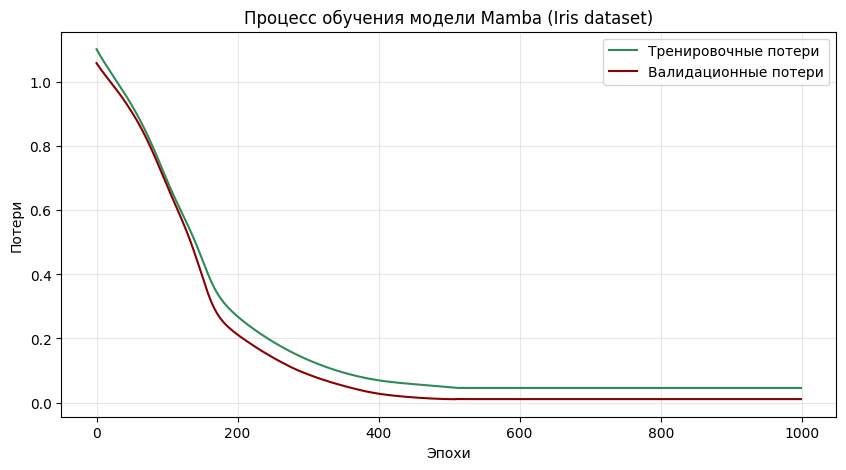


Точность на тренировочных данных: 0.9810
Точность на тестовых данных: 1.0000


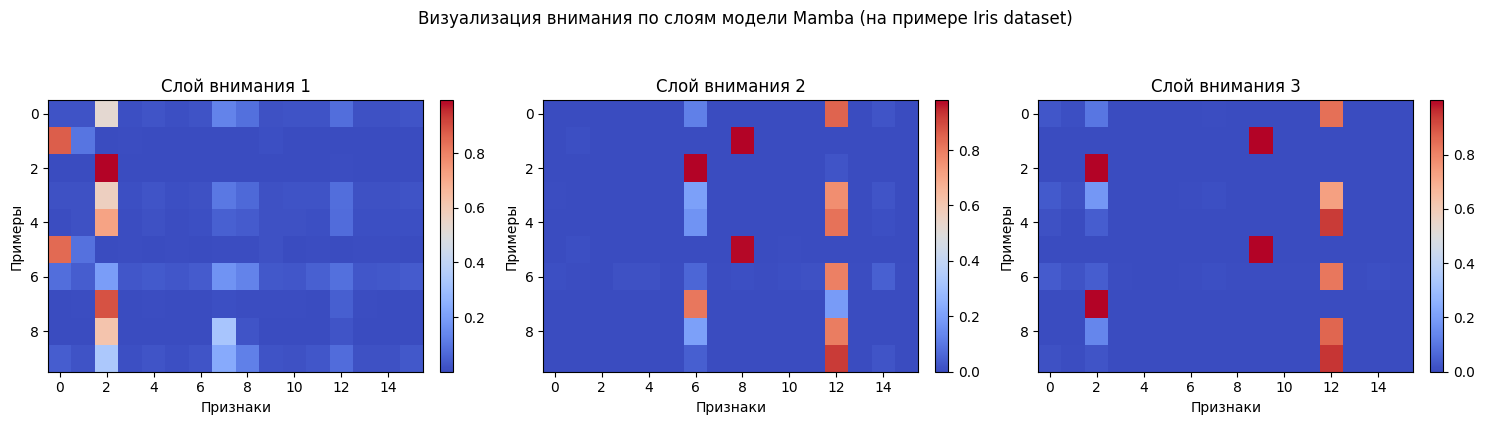

In [4]:
# Подавление предупреждений
import warnings
warnings.filterwarnings("ignore")

# Импорт необходимых библиотек
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Преобразование в тензоры
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

class MambaBlock(nn.Module):
    def __init__(self, d_input, d_model):
        super().__init__()
        self.expansion = nn.Linear(d_input, d_model)
        self.attention = nn.Linear(d_model, d_model)
        self.contraction = nn.Linear(d_model, d_input)
        self.activation = nn.GELU()

    def forward(self, x):
        residual = x
        x = self.activation(self.expansion(x))
        attn_weights = torch.softmax(self.attention(x), dim=1)
        x = attn_weights * x
        x = self.contraction(x)
        return x + residual, attn_weights

class IrisMamba(nn.Module):
    """Модель Mamba для классификации Iris"""
    def __init__(self, input_dim=4, hidden_dim=16, num_layers=3, num_classes=3):
        super().__init__()
        self.layers = nn.ModuleList([MambaBlock(input_dim, hidden_dim) for _ in range(num_layers)])
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        attention_maps = []
        for layer in self.layers:
            x, attn = layer(x)
            attention_maps.append(attn)
        return self.classifier(x), attention_maps

# Инициализация модели
model = IrisMamba().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

# Обучение модели
num_epochs = 1000
loss_history = []

print("Старт обучения модели...")
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs, _ = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs, _ = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)

    scheduler.step(val_loss)
    loss_history.append((loss.item(), val_loss.item()))

    if (epoch + 1) % 50 == 0:
        print(f"Эпоха {epoch+1}/{num_epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

# Визуализация процесса обучения
plt.figure(figsize=(10, 5))
train_losses, val_losses = zip(*loss_history)
plt.plot(train_losses, label='Тренировочные потери', color='#2E8B57')
plt.plot(val_losses, label='Валидационные потери', color='#8B0000')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.title('Процесс обучения модели Mamba (Iris dataset)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Оценка точности
def calculate_accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        outputs, _ = model(X)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y).float().mean()
    return accuracy.item()

train_accuracy = calculate_accuracy(model, X_train_tensor, y_train_tensor)
test_accuracy = calculate_accuracy(model, X_test_tensor, y_test_tensor)

print(f"\nТочность на тренировочных данных: {train_accuracy:.4f}")
print(f"Точность на тестовых данных: {test_accuracy:.4f}")

# Визуализация внимания
model.eval()
with torch.no_grad():
    _, attn_maps = model(X_test_tensor[:10])  # Визуализируем только для первых 10 примеров

    fig, axes = plt.subplots(1, len(attn_maps), figsize=(15, 4))
    plt.suptitle("Визуализация внимания по слоям модели Mamba (на примере Iris dataset)", y=1.05)

    for i, (attn, ax) in enumerate(zip(attn_maps, axes)):
        attn_np = attn.cpu().numpy()
        im = ax.imshow(attn_np, cmap='coolwarm', aspect='auto')
        ax.set_title(f'Слой внимания {i+1}')
        ax.set_xlabel('Признаки')
        ax.set_ylabel('Примеры')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

***Интерпретация внимания***

**Слой внимания 1**
*   Распределение внимания более равномерное.
*   Некоторые примеры (например, 1, 3, 5) демонстрируют повышенное внимание к определённым признакам (приблизительно 0–4 и 12–15).
*   Это указывает на раннюю стадию обработки, где модель лишь начинает выделять важные признаки.

**Слой внимания 2**
* Фокус внимания становится более чётким.

**Слой внимания 3**
* Акцент внимания ещё больше узконаправлен.
* Высокие значения сосредоточены на признаках 2, 12 и 13 в различных примерах.
* Такая спецификация указывает на то, что модель уже использует определённые шаблоны для принятия решений.

***Как модель воспринимает данные и принимает решения***
* Каждый последующий слой уточняет, на какие признаки стоит обращать внимание. Это напоминает процесс человеческого мышления: сначала общий анализ, затем детализация.

* Внимание модели зависит от конкретного примера. Например, в примере 7 (слой 3) акцент сделан на признаке 2, тогда как в примере 12 — на признаке 12. Это говорит о том, что модель учитывает особенности каждого объекта.

* Несмотря на то, что в Iris всего 4 признака, модель работает с увеличенной размерностью (d_model=16). Это позволяет ей выявлять скрытые взаимосвязи между признаками.
